In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# =========================
# Dataset Generators
# =========================

def generate_xor_dataset(total_samples):
    X_base = np.array([[0,0,1,1],
                       [0,1,0,1]])
    Y_base = np.array([[0,1,1,0]])

    repeats = total_samples // 4
    X = np.repeat(X_base, repeats, axis=1)
    Y = np.repeat(Y_base, repeats, axis=1)

    X = X + 0.05 * np.random.randn(*X.shape)

    perm = np.random.permutation(X.shape[1])
    return X[:, perm], Y[:, perm]


def generate_cosine_dataset(n):
    X = np.random.uniform(-np.pi, np.pi, (2, n))  # (2, n)

    Y = np.cos(X[0, :] + X[1, :]).reshape(1, n)
    X = X+0.05 * np.random.randn(*X.shape)

    perm = np.random.permutation(n)
    return X[:, perm], Y[:, perm]
# =========================
# Neural Network Class
# =========================

class SimpleNN:

    def __init__(self, input_dim, hidden_dim, output_dim, task="xor"):
        self.task = task

        self.W1 = 0.01 * np.random.randn(hidden_dim, input_dim)
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = 0.01 * np.random.randn(output_dim, hidden_dim)
        self.b2 = np.zeros((output_dim, 1))

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def forward(self, X):
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = np.tanh(self.Z1)
        self.Z2 = np.dot(self.W2, self.A1) + self.b2

        if self.task == "xor":
            self.Y_hat = self.sigmoid(self.Z2)
        else:  # cosine
            self.Y_hat = self.Z2

        return self.Y_hat

    def compute_loss(self, Y):
        m = Y.shape[1]

        if self.task == "xor":
            eps = 1e-8
            loss = -(1/m) * np.sum(
                Y*np.log(self.Y_hat + eps) +
                (1-Y)*np.log(1-self.Y_hat + eps)
            )
        else:
            loss = (1/m) * np.sum((self.Y_hat - Y)**2)

        return loss

    def backward(self, X, Y):
        m = X.shape[1]

        dZ2 = self.Y_hat - Y

        dW2 = (1/m) * np.dot(dZ2, self.A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * (1 - self.A1**2)

        dW1 = (1/m) * np.dot(dZ1, X.T)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        return dW1, db1, dW2, db2

    def update(self, dW1, db1, dW2, db2, lr):
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

    def accuracy(self, Y):
        predictions = (self.Y_hat > 0.5)
        return np.mean(predictions == Y)

    def train(self, X, Y, epochs=3000, lr=0.5, batch_size=None):
      split = int(0.8 * X.shape[1])
      X_train, Y_train = X[:, :split], Y[:, :split]
      X_test, Y_test = X[:, split:], Y[:, split:]

      m_train = X_train.shape[1]

      if batch_size is None:
        batch_size = m_train  # full batch

      train_losses = []
      test_losses = []
      train_accs = []
      test_accs = []

      for epoch in range(epochs):
        # shuffle every epoch
        perm = np.random.permutation(m_train)
        X_train = X_train[:, perm]
        Y_train = Y_train[:, perm]

        for i in range(0, m_train, batch_size):

            X_batch = X_train[:, i:i+batch_size]
            Y_batch = Y_train[:, i:i+batch_size]

            self.forward(X_batch)
            dW1, db1, dW2, db2 = self.backward(X_batch, Y_batch)
            self.update(dW1, db1, dW2, db2, lr)

        # evaluate once per epoch
        self.forward(X_train)
        train_losses.append(self.compute_loss(Y_train))

        self.forward(X_test)
        test_losses.append(self.compute_loss(Y_test))

        if self.task == "xor":
            self.forward(X_train)
            train_accs.append(self.accuracy(Y_train))

            self.forward(X_test)
            test_accs.append(self.accuracy(Y_test))
      return train_losses, test_losses, train_accs, test_accs

## Network Architecture

We implement a simple feedforward neural network with:

Input layer: 2 nodes

Hidden layer: 2 neurons

Output layer: 1 neuron

Parameter dimensions:

$$W^{(1)}∈R^{2\times2}$$
$$b^{(1)}∈R^{2\times1}$$
$$W^{(2)}∈R^{1\times2}$$
$$b^{(2)}∈R^{1\times1}$$

## Forward Propagation

$$X∈R^{2\times m}$$
where m is the number of training samples.

Hidden Layer
$$Z^{(1)} = W^{(1)}X+b^{(1)}$$
$$A^{(1)} = tanh(Z^{(1)})$$
Derivative of tanh:
$$\frac{d}{dz}tanh(Z)=1-tanh^2(Z)$$
Output layer
$$Z^{(2)} = W^{(2)}A^{(1)}+b^{(2)}$$

Two cases:

Case 1: XOR (Classification)

Output activation:

$$\hat{y}=\sigma(Z^{(2)})=\frac{1}{1+e^{-Z^{(2)}}}$$
	​


Binary Cross Entropy Loss:
$$
L = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$
Case 2: Cosine (Regression)

Linear output:
$$\hat{y}=Z^{(2)}$$

Mean Squared Error (MSE):
$$
L = \frac{1}{2}(y - \hat{y})^2
$$

## Backpropagation

Using chain rule:

Output Layer Gradient

For both XOR and Cosine:
$$
dZ^{(2)} = \hat{y} - y
$$

$$
dW^{(2)} = \frac{1}{m} \, dZ^{(2)} {A^{(1)}}^{T}
$$

$$
db^{(2)} = \frac{1}{m} \sum dZ^{(2)}
$$

Hidden Layer Gradient
$$
dA^{(1)} = {W^{(2)}}^{T} dZ^{(2)}
$$

$$
dZ^{(1)} = dA^{(1)} \odot (1 - {A^{(1)}}^2)
$$

$$
dW^{(1)} = \frac{1}{m} \, dZ^{(1)} X^{T}
$$

$$
db^{(1)} = \frac{1}{m} \sum_{i=1}^{m} {dZ^{(1)}}^{(i)}
$$

## Gradient Descent Update Rule

Parameters are updated as:


$$
W \leftarrow W - \eta \frac{\partial L}{\partial W}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

where
𝜂 is the learning rate

Epoch 0, train loss: 0.6931, train accuracy: 0.5031, test loss: 0.6932, test accuracy: 0.4875
Epoch 300, train loss: 0.6931, train accuracy: 0.5031, test loss: 0.6933, test accuracy: 0.4875
Epoch 600, train loss: 0.6931, train accuracy: 0.5031, test loss: 0.6935, test accuracy: 0.4875
Epoch 900, train loss: 0.6929, train accuracy: 0.7625, test loss: 0.6945, test accuracy: 0.7000
Epoch 1200, train loss: 0.6820, train accuracy: 0.7594, test loss: 0.6936, test accuracy: 0.6875
Epoch 1500, train loss: 0.0477, train accuracy: 1.0000, test loss: 0.0476, test accuracy: 1.0000
Epoch 1800, train loss: 0.0151, train accuracy: 1.0000, test loss: 0.0150, test accuracy: 1.0000
Epoch 2100, train loss: 0.0088, train accuracy: 1.0000, test loss: 0.0088, test accuracy: 1.0000
Epoch 2400, train loss: 0.0062, train accuracy: 1.0000, test loss: 0.0062, test accuracy: 1.0000
Epoch 2700, train loss: 0.0048, train accuracy: 1.0000, test loss: 0.0047, test accuracy: 1.0000


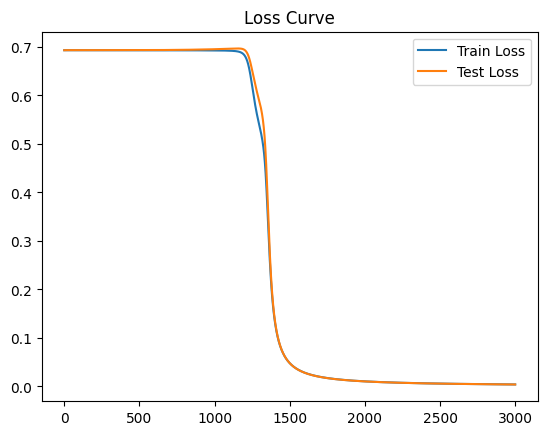

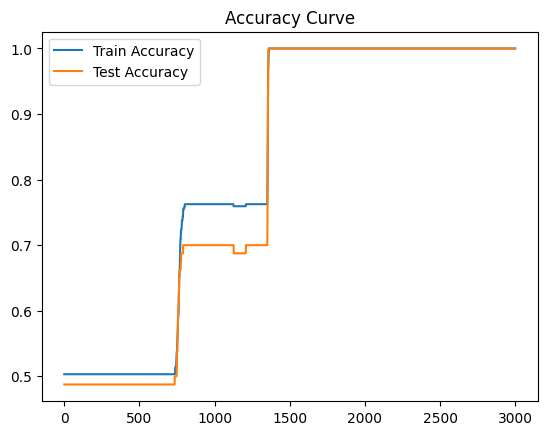

In [2]:
X, Y = generate_xor_dataset(400)

model = SimpleNN(input_dim=2, hidden_dim=2, output_dim=1,
                 task="xor")
epochs =3000
lr=0.5
train_losses, test_losses, train_accs, test_accs = model.train(
    X, Y, epochs=3000, lr=0.5,batch_size=None
)
for epoch in range(epochs):
  if epoch % 300 == 0:
    print(f"Epoch {epoch}, "
      f"train loss: {train_losses[epoch]:.4f}, "
      f"train accuracy: {train_accs[epoch]:.4f}, "
      f"test loss: {test_losses[epoch]:.4f}, "
      f"test accuracy: {test_accs[epoch]:.4f}")
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [3]:
for n in [50, 200, 300]:
  X, Y = generate_xor_dataset(n)
  model = SimpleNN(input_dim=2, hidden_dim=2, output_dim=1,
                 task="xor")
  epochs =3000
  lr=0.5
  train_losses, test_losses, train_accs, test_accs = model.train(
    X, Y, epochs=3000, lr=0.5
)
  for epoch in range(epochs):
    if epoch % 1000 == 0:
      print(f"-----n:{n}-----")
      print(f"Epoch {epoch}, "
      f"train loss: {train_losses[epoch]:.4f}, "
      f"train accuracy: {train_accs[epoch]:.4f}, "
      f"test loss: {test_losses[epoch]:.4f}, "
      f"test accuracy: {test_accs[epoch]:.4f}")

-----n:50-----
Epoch 0, train loss: 0.6928, train accuracy: 0.5263, test loss: 0.6945, test accuracy: 0.4000
-----n:50-----
Epoch 1000, train loss: 0.0299, train accuracy: 1.0000, test loss: 0.0299, test accuracy: 1.0000
-----n:50-----
Epoch 2000, train loss: 0.0054, train accuracy: 1.0000, test loss: 0.0053, test accuracy: 1.0000
-----n:200-----
Epoch 0, train loss: 0.6930, train accuracy: 0.5188, test loss: 0.6939, test accuracy: 0.4250
-----n:200-----
Epoch 1000, train loss: 0.5042, train accuracy: 0.7750, test loss: 0.6150, test accuracy: 0.6500
-----n:200-----
Epoch 2000, train loss: 0.0070, train accuracy: 1.0000, test loss: 0.0075, test accuracy: 1.0000
-----n:300-----
Epoch 0, train loss: 0.6931, train accuracy: 0.5042, test loss: 0.6932, test accuracy: 0.4833
-----n:300-----
Epoch 1000, train loss: 0.6927, train accuracy: 0.5167, test loss: 0.6955, test accuracy: 0.4333
-----n:300-----
Epoch 2000, train loss: 0.0154, train accuracy: 1.0000, test loss: 0.0158, test accuracy: 1.

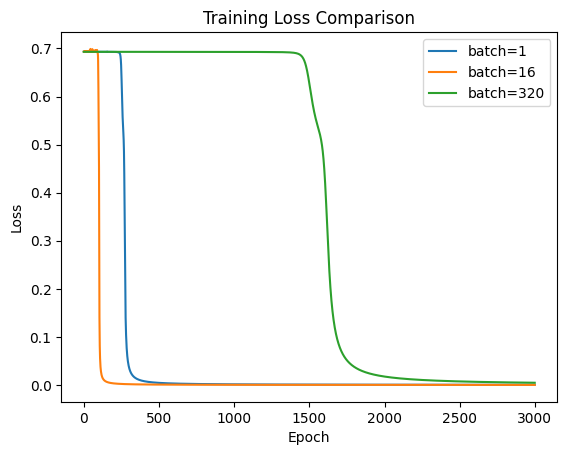

In [4]:
plt.figure()
X, Y = generate_xor_dataset(400)
for m in [1, 16, 320]:
  model = SimpleNN(input_dim=2, hidden_dim=2, output_dim=1,
                 task="xor")
  train_losses, _, _, _ = model.train(
        X, Y, epochs=3000, lr=0.5 if m!=1 else 0.01, batch_size=m
    )
  plt.plot(train_losses, label=f"batch={m}")
plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Epoch 0, train loss: 0.5056, test loss: 0.4775 
Epoch 300, train loss: 0.5030, test loss: 0.4771 
Epoch 600, train loss: 0.4908, test loss: 0.4582 
Epoch 900, train loss: 0.4339, test loss: 0.3631 
Epoch 1200, train loss: 0.4295, test loss: 0.3543 
Epoch 1500, train loss: 0.4273, test loss: 0.3493 
Epoch 1800, train loss: 0.4261, test loss: 0.3463 
Epoch 2100, train loss: 0.4253, test loss: 0.3445 
Epoch 2400, train loss: 0.4247, test loss: 0.3434 
Epoch 2700, train loss: 0.4243, test loss: 0.3427 


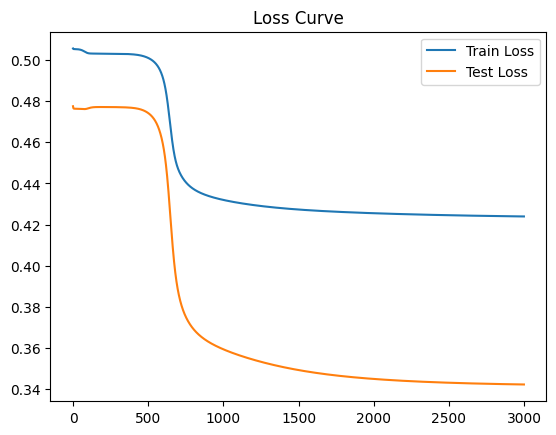

In [5]:
X, Y = generate_cosine_dataset(400)

model = SimpleNN(input_dim=2, hidden_dim=2, output_dim=1,
                 task="cosine")

train_losses, test_losses, _, _ = model.train(
    X, Y, epochs=3000, lr=0.4
)

for epoch in range(epochs):
  if epoch % 300 == 0:
    print(f"Epoch {epoch}, "
      f"train loss: {train_losses[epoch]:.4f}, "
      f"test loss: {test_losses[epoch]:.4f} ")
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [6]:
for n in [50, 200, 300]:
  X, Y = generate_cosine_dataset(n)
  model = SimpleNN(input_dim=2, hidden_dim=2, output_dim=1,
                 task="cosine")
  epochs =3000
  lr=0.1
  train_losses, test_losses, train_accs, test_accs = model.train(
    X, Y, epochs=3000, lr=0.1
)
  for epoch in range(epochs):
    if epoch % 300 == 0:
      print(f"Epoch {epoch}, "
      f"train loss: {train_losses[epoch]:.4f}, "
      f"test loss: {test_losses[epoch]:.4f} ")


Epoch 0, train loss: 0.5293, test loss: 0.3489 
Epoch 300, train loss: 0.4818, test loss: 0.3785 
Epoch 600, train loss: 0.4396, test loss: 0.4402 
Epoch 900, train loss: 0.1377, test loss: 0.1140 
Epoch 1200, train loss: 0.1281, test loss: 0.0891 
Epoch 1500, train loss: 0.1267, test loss: 0.0865 
Epoch 1800, train loss: 0.1257, test loss: 0.0848 
Epoch 2100, train loss: 0.1248, test loss: 0.0834 
Epoch 2400, train loss: 0.1241, test loss: 0.0823 
Epoch 2700, train loss: 0.1234, test loss: 0.0813 
Epoch 0, train loss: 0.4982, test loss: 0.5421 
Epoch 300, train loss: 0.4877, test loss: 0.5613 
Epoch 600, train loss: 0.4556, test loss: 0.5655 
Epoch 900, train loss: 0.1310, test loss: 0.2046 
Epoch 1200, train loss: 0.1016, test loss: 0.1628 
Epoch 1500, train loss: 0.1001, test loss: 0.1607 
Epoch 1800, train loss: 0.0990, test loss: 0.1596 
Epoch 2100, train loss: 0.0981, test loss: 0.1588 
Epoch 2400, train loss: 0.0974, test loss: 0.1582 
Epoch 2700, train loss: 0.0968, test loss: 

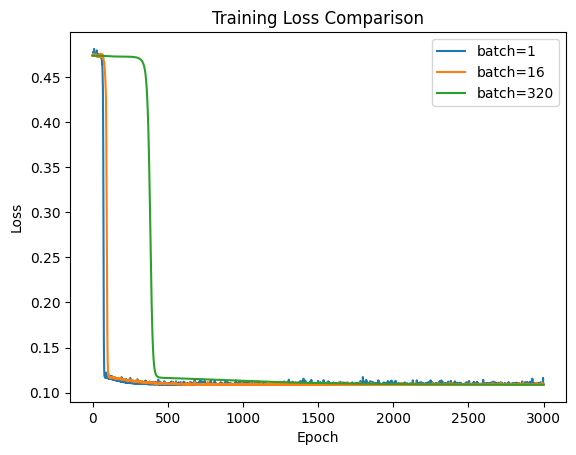

In [7]:
plt.figure()
X, Y = generate_cosine_dataset(400)
for m in [1, 16, 320]:
  if m == 1:
    lr = 0.01
  elif m == 16:
    lr = 0.1
  else:
    lr = 0.5
  model = SimpleNN(input_dim=2, hidden_dim=2, output_dim=1,
                 task="cosine")
  train_losses, _, _, _ = model.train(
        X, Y, epochs=3000, lr=lr, batch_size=m
    )
  plt.plot(train_losses, label=f"batch={m}")
plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()